In [1]:
"""
ts - desparramo espectral (spectral leakage)
pds - utn

idea del ts: agarrar una senoidal que cae justo en un bin de la dft
(fenomeno "amigable") y compararla contra dos versiones desintonizadas
apenas un poquito, para ver como se rompe la idealidad y el espectro
se "desparrama" en vez de dar un unico palito.
"""

'\nts - desparramo espectral (spectral leakage)\npds - utn\n\nidea del ts: agarrar una senoidal que cae justo en un bin de la dft\n(fenomeno "amigable") y compararla contra dos versiones desintonizadas\napenas un poquito, para ver como se rompe la idealidad y el espectro\nse "desparrama" en vez de dar un unico palito.\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
n = 1000   # muestras
fs = 1000  # hz

# resolucion espectral: cuanto vale un bin de la dft en hz.
# esto sale de que la dft muestrea el espectro continuo en fs/n hz.
df = fs / n   # = 1 hz por bin

# elegimos k0 = n/4 a proposito: asi f0 = k0*df cae exacto en un bin,
# osea que en la ventana de n muestras entra un numero entero de ciclos.
k0 = n / 4
f0 = k0 * df   # 250 hz

# ahora generamos tres frecuencias: la "perfecta" (f0) y dos vecinas,
# corridas una fraccion de bin (k0 = n/4, n/4+0.25, n/4+0.5). la gracia
# es ver que tan poquito hace falta desintonizar para que el espectro
# deje de verse limpio.
f1 = f0
f2 = f0 + 0.25 * df   # desintonia de un cuarto de bin
f3 = f0 + 0.5 * df    # desintonia de medio bin (la peor de las tres)

tt = (np.arange(n) / fs).reshape(n, 1)   # tt[i] = i/fs, vector nx1


def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    # la misma funcion de ts1, la reciclamos tal cual
    nn_vec = np.arange(nn).reshape(nn, 1)
    t = nn_vec / fs
    x = dc + vmax * np.sin(2 * np.pi * ff * t + ph)
    return t, x


def normalizar_potencia(x):
    # dividir por el desvio estandar deja varianza (=potencia, porque
    # la senoidal tiene media 0) en 1. esto es lo que pide el enunciado
    # como "potencia normalizada".
    return x / np.std(x)


_, x1 = mi_funcion_sen(1, 0, f1, 0, n, fs)
_, x2 = mi_funcion_sen(1, 0, f2, 0, n, fs)
_, x3 = mi_funcion_sen(1, 0, f3, 0, n, fs)

x1 = normalizar_potencia(x1)
x2 = normalizar_potencia(x2)
x3 = normalizar_potencia(x3)

In [4]:
def psd(x, fs, n_datos=None):
    """
    periodograma de x, calculado como |x[k]|^2, pero normalizado para
    que al sumar todos los bins recuperemos la potencia real de la señal
    (esto es parseval).

    ojo con n_datos: si a x le agregamos ceros al final (zero padding),
    la cantidad de muestras con "energia de verdad" sigue siendo la
    original, no la longitud total del vector con ceros. si normalizas
    por la longitud del fft en vez de por n_datos, te da una potencia
    total distinta segun cuanto padding metiste, lo cual no tiene
    sentido fisico (agregar ceros no agrega ni saca energia).
    """
    x = x.flatten()
    n_fft = len(x)
    if n_datos is None:
        n_datos = n_fft

    xf = np.fft.fft(x)
    sxx = (np.abs(xf) ** 2) / (n_fft * n_datos)
    ff = np.arange(n_fft) * fs / n_fft
    return ff, sxx


ff1, sxx1 = psd(x1, fs)
ff2, sxx2 = psd(x2, fs)
ff3, sxx3 = psd(x3, fs)

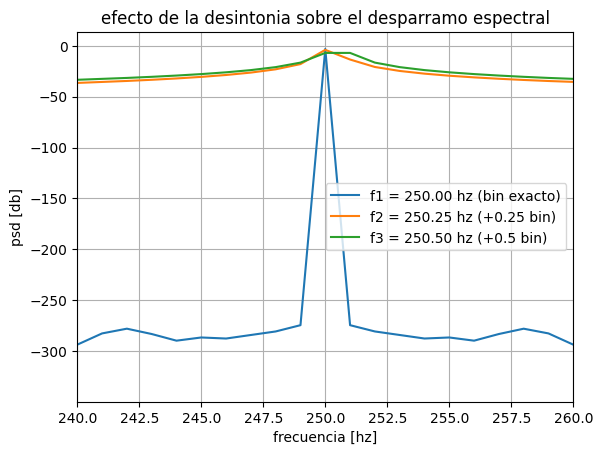

In [5]:
plt.figure()
plt.plot(ff1[:n // 2], 10 * np.log10(sxx1[:n // 2]), label=f'f1 = {f1:.2f} hz (bin exacto)')
plt.plot(ff2[:n // 2], 10 * np.log10(sxx2[:n // 2]), label=f'f2 = {f2:.2f} hz (+0.25 bin)')
plt.plot(ff3[:n // 2], 10 * np.log10(sxx3[:n // 2]), label=f'f3 = {f3:.2f} hz (+0.5 bin)')
plt.xlim([f0 - 10, f0 + 10])
plt.xlabel('frecuencia [hz]')
plt.ylabel('psd [db]')
plt.title('efecto de la desintonia sobre el desparramo espectral')
plt.legend()
plt.grid(True)
plt.show()

# lo que se espera ver: x1 da un unico pico bien angosto (idealmente
# un impulso, salvo por la resolucion finita). x2, con un cuarto de bin
# de corrimiento, ya muestra energia "fugada" a los bines vecinos. x3,
# con medio bin de corrimiento, es el peor caso posible: la frecuencia
# queda exactamente a mitad de camino entre dos bins de la dft, asi que
# ninguno de los dos "atrapa" el pico y el desparramo es maximo (pico
# mas bajo y mas ancho, lobulos laterales bien visibles).

In [6]:
print(f'potencia x1 (suma de la psd): {np.sum(sxx1):.4f}')
print(f'potencia x2 (suma de la psd): {np.sum(sxx2):.4f}')
print(f'potencia x3 (suma de la psd): {np.sum(sxx3):.4f}')

# las tres deberian dar ~1 (por parseval, la suma de la psd en todos los
# bines es igual a la potencia de la señal en el tiempo, y las armamos
# con varianza unitaria a proposito). o sea que las tres tienen la misma
# potencia total, aunque su pinta en frecuencia sea tan distinta.
#
# la razon de esa diferencia de "pinta" no es la potencia, es como la
# dft reparte esa potencia entre los bines. la dft asume (implicitamente)
# que las n muestras que le diste son un periodo de una señal periodica.
# si f0 completa un numero entero de ciclos en la ventana de n muestras,
# esa extension periodica es perfectamente continua (empalma la muestra
# n-1 con la 0 sin sobresalto) y toda la potencia cae en un solo bin.
# si la frecuencia no es un multiplo exacto de fs/n, al repetir la
# ventana aparece un salto (discontinuidad) en el borde. esa
# discontinuidad, vista en frecuencia, es equivalente a haber
# multiplicado la senoidal infinita por una ventana rectangular: el
# espectro real es la convolucion del impulso ideal con la transformada
# de esa ventana (un sinc / dirichlet kernel), que tiene lobulos
# laterales que no se cancelan salvo que la frecuencia caiga justo en
# un bin. por eso una diferencia de pocos hz (menos de un bin) alcanza
# para que el espectro se vea completamente distinto: no cambio la
# potencia de la señal, cambio como la ventana finita "corta" esa
# senoidal y la particion en frecuencia que arma la dft.

potencia x1 (suma de la psd): 1.0000
potencia x2 (suma de la psd): 1.0000
potencia x3 (suma de la psd): 1.0000


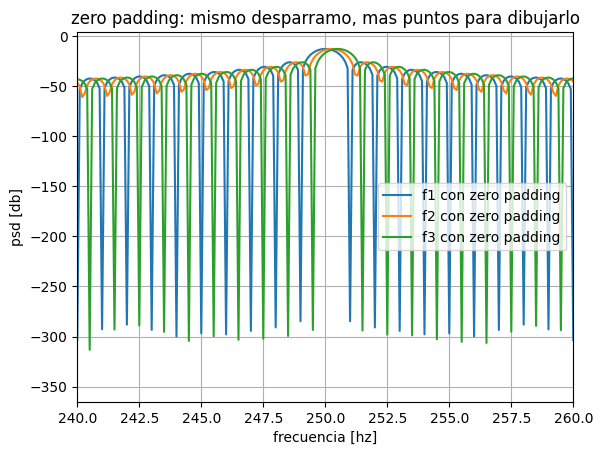

potencia x1 con padding: 1.0000
potencia x2 con padding: 1.0000
potencia x3 con padding: 1.0000


In [7]:
# le agregamos 9*n ceros al final de cada señal. esto no le suma
# informacion nueva a la señal (los ceros no tienen energia), lo unico
# que hace es que el fft evalua el espectro en mas puntos de frecuencia
# (achica el paso df = fs/n_fft porque n_fft ahora es mas grande).
# es decir, interpola el espectro con mas resolucion de grilla, pero no
# mejora la resolucion real, que depende de cuantas muestras de señal
# genuina metimos (eso sigue siendo n). el ancho del lobulo principal
# del leakage no cambia, solo lo vemos mas "suavecito" y con mas detalle.

ceros = np.zeros((9 * n, 1))

x1_pad = np.vstack((x1, ceros))
x2_pad = np.vstack((x2, ceros))
x3_pad = np.vstack((x3, ceros))

# le pasamos n_datos=n a proposito: la potencia real sigue estando
# repartida en n muestras, no en las 10*n que tiene el vector ahora.
ff1p, sxx1p = psd(x1_pad, fs, n_datos=n)
ff2p, sxx2p = psd(x2_pad, fs, n_datos=n)
ff3p, sxx3p = psd(x3_pad, fs, n_datos=n)

plt.figure()
plt.plot(ff1p[:len(ff1p) // 2], 10 * np.log10(sxx1p[:len(ff1p) // 2]), label='f1 con zero padding')
plt.plot(ff2p[:len(ff2p) // 2], 10 * np.log10(sxx2p[:len(ff2p) // 2]), label='f2 con zero padding')
plt.plot(ff3p[:len(ff3p) // 2], 10 * np.log10(sxx3p[:len(ff3p) // 2]), label='f3 con zero padding')
plt.xlim([f0 - 10, f0 + 10])
plt.xlabel('frecuencia [hz]')
plt.ylabel('psd [db]')
plt.title('zero padding: mismo desparramo, mas puntos para dibujarlo')
plt.legend()
plt.grid(True)
plt.show()

print(f'potencia x1 con padding: {np.sum(sxx1p):.4f}')
print(f'potencia x2 con padding: {np.sum(sxx2p):.4f}')
print(f'potencia x3 con padding: {np.sum(sxx3p):.4f}')

# con padding se ve mucho mejor la forma completa del lobulo principal y
# los lobulos laterales de x2 y x3 (antes, con solo n puntos, un monton
# de esa forma quedaba "entre" dos muestras de la dft y no se veia).
# pero el ancho del lobulo principal en hz es el mismo que sin padding,
# y las potencias siguen dando ~1: agregar ceros no cambia ni la
# potencia de la señal ni cuanto se desparrama, solo la resolucion con
# la que estamos graficando ese desparramo.